In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('affairs.csv', )
df = df.iloc[:,1:]
df

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666
...,...,...,...,...,...,...,...,...,...
6361,5.0,32.0,13.0,2.0,3.0,17.0,4.0,3.0,0.000000
6362,4.0,32.0,13.0,1.0,1.0,16.0,5.0,5.0,0.000000
6363,5.0,22.0,2.5,0.0,2.0,14.0,3.0,1.0,0.000000
6364,5.0,32.0,6.0,1.0,3.0,14.0,3.0,4.0,0.000000


In [3]:
# ============================================
# Affairs 이진분류: Train/Val/Test + K-Fold + 튜닝 + 임계값 최적화 (수정본)
# ============================================
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# --------------------------------------------
# 0) 가정: df(DataFrame)가 이미 존재
#    컬럼: ['rate_marriage','age','yrs_married','children','religious',
#           'educ','occupation','occupation_husb','affairs']
# --------------------------------------------

# 1) 타깃 생성
df = df.copy()
df['affair_flag'] = (df['affairs'] > 0).astype(int)

# 2) Train / Test 분리 (홀드아웃)
X_full = df.drop(columns=['affairs', 'affair_flag'])
y_full = df['affair_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# 3) 피처 엔지니어링 함수 (신규 컬럼 2개 생성)
ENGINEERED_COLS = ['yrs_per_age', 'rate_x_yrs']

def add_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X['yrs_per_age'] = (X['yrs_married'] / X['age']).replace([np.inf, -np.inf], np.nan).fillna(0)
    X['rate_x_yrs'] = X['rate_marriage'] * X['yrs_married']
    return X.drop(columns=['yrs_married'])

# ✅ 핵심 수정: feature_names_out을 callable로 지정 (입력컬럼 + 신규컬럼 반환)
def feat_names_out(transformer, input_features):
    keep = [c for c in input_features if c != 'yrs_married']
    return keep + ENGINEERED_COLS


feat_eng = FunctionTransformer(
    add_features,
    validate=False,
    feature_names_out=feat_names_out
)

# 4) 컬럼 타입 정의
categorical_cols = ['occupation', 'occupation_husb']
# ✅ 신규 엔지니어드 컬럼을 numeric 목록에 포함 (파이프라인에서 feat_eng 이후에 prep이 참조)
numeric_cols = [c for c in X_train.columns
                if c not in categorical_cols and c != 'yrs_married'] + ENGINEERED_COLS

# 5) 전처리 파이프라인
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ],
    remainder='drop'
)

# 6) 모델 정의
logreg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'
)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 7) 파이프라인
pipe_logreg = Pipeline(steps=[
    ('feat', feat_eng),
    ('prep', preprocessor),
    ('clf', logreg)
])

pipe_rf = Pipeline(steps=[
    ('feat', feat_eng),
    ('prep', preprocessor),
    ('clf', rf)
])

# 8) K-Fold & 스코어링
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'acc': 'accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc'
}

# 9) 기본 K-Fold 성능 비교
print("=== 5-Fold CV: Logistic Regression ===")
cv_log = cross_validate(pipe_logreg, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
for k, v in cv_log.items():
    if k.startswith('test_'):
        print(f"{k.replace('test_', '').upper():>9}: {np.mean(v):.4f} ± {np.std(v):.4f}")

print("\n=== 5-Fold CV: Random Forest ===")
cv_rf = cross_validate(pipe_rf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
for k, v in cv_rf.items():
    if k.startswith('test_'):
        print(f"{k.replace('test_', '').upper():>9}: {np.mean(v):.4f} ± {np.std(v):.4f}")

# 10) GridSearchCV (ROC AUC 기준)
param_grid_logreg = {
    'clf__C': [0.1, 1.0, 5.0, 10.0],
    'clf__penalty': ['l2']
}
param_grid_rf = {
    'clf__n_estimators': [300, 500],
    'clf__max_depth': [None, 8, 12],
    'clf__min_samples_leaf': [1, 3, 5]
}

print("\n=== GridSearchCV: Logistic Regression (ROC AUC) ===")
gs_log = GridSearchCV(
    estimator=pipe_logreg, param_grid=param_grid_logreg,
    scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0
)
gs_log.fit(X_train, y_train)
print("Best ROC AUC:", gs_log.best_score_)
print("Best Params:", gs_log.best_params_)

print("\n=== GridSearchCV: Random Forest (ROC AUC) ===")
gs_rf = GridSearchCV(
    estimator=pipe_rf, param_grid=param_grid_rf,
    scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0
)
gs_rf.fit(X_train, y_train)
print("Best ROC AUC:", gs_rf.best_score_)
print("Best Params:", gs_rf.best_params_)

# 11) 베스트 모델 선택
best_model = gs_rf if gs_rf.best_score_ >= gs_log.best_score_ else gs_log
print("\n=== Selected Best Model:", type(best_model.best_estimator_['clf']).__name__, "===")

# 12) 임계값 최적화 (OOF 기반 F1 최대화)
oof_proba = cross_val_predict(
    best_model.best_estimator_, X_train, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.2, 0.8, 61)
f1s = []
for th in thresholds:
    preds = (oof_proba >= th).astype(int)
    f1s.append(f1_score(y_train, preds))
best_th = thresholds[int(np.argmax(f1s))]
print(f"\nBest threshold by OOF F1: {best_th:.3f}  (F1={np.max(f1s):.4f})")

# 13) 전체 Train 재학습 후 Test 평가
best_est = best_model.best_estimator_
best_est.fit(X_train, y_train)

test_proba = best_est.predict_proba(X_test)[:, 1]
test_pred_default = (test_proba >= 0.5).astype(int)
test_pred_bestth = (test_proba >= best_th).astype(int)

def evaluate(y_true, y_pred, y_proba, tag=""):
    print(f"\n=== Test Evaluation ({tag}) ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1       : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

evaluate(y_test, test_pred_default, test_proba, tag="threshold=0.50")
evaluate(y_test, test_pred_bestth, test_proba, tag=f"threshold={best_th:.2f}")


=== 5-Fold CV: Logistic Regression ===
      ACC: 0.6982 ± 0.0121
       F1: 0.5874 ± 0.0170
PRECISION: 0.5252 ± 0.0145
   RECALL: 0.6663 ± 0.0206
  ROC_AUC: 0.7550 ± 0.0132

=== 5-Fold CV: Random Forest ===
      ACC: 0.6901 ± 0.0038
       F1: 0.4915 ± 0.0068
PRECISION: 0.5221 ± 0.0068
   RECALL: 0.4647 ± 0.0151
  ROC_AUC: 0.7045 ± 0.0042

=== GridSearchCV: Logistic Regression (ROC AUC) ===
Best ROC AUC: 0.7550808522456838
Best Params: {'clf__C': 0.1, 'clf__penalty': 'l2'}

=== GridSearchCV: Random Forest (ROC AUC) ===
Best ROC AUC: 0.7572943627711684
Best Params: {'clf__max_depth': 8, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 500}

=== Selected Best Model: RandomForestClassifier ===

Best threshold by OOF F1: 0.480  (F1=0.5953)

=== Test Evaluation (threshold=0.50) ===
Accuracy : 0.6593
Precision: 0.4788
Recall   : 0.6326
F1       : 0.5451
ROC AUC  : 0.7229

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.67      0.

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

def evaluate_with_threshold(model, X, y, threshold=0.5):
    """
    학습된 모델(model)과 데이터(X, y)를 받아서
    임계값(threshold)에 따라 성능 지표 출력
    """
    # 예측 확률
    y_proba = model.predict_proba(X)[:, 1]
    # 임계값 적용
    y_pred = (y_proba >= threshold).astype(int)
    
    # 성능 지표
    print(f"\n=== Evaluation (threshold={threshold:.2f}) ===")
    print(f"Accuracy : {accuracy_score(y, y_pred):.4f}")
    print(f"Precision: {precision_score(y, y_pred):.4f}")
    print(f"Recall   : {recall_score(y, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y, y_pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y, y_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))
    
    return y_pred, y_proba

# ---------------------------------
# 사용 예시
# ---------------------------------
# best_est 는 이미 학습된 최종 모델이라고 가정

# 기본 임계값 0.5로 평가
evaluate_with_threshold(best_est, X_test, y_test, threshold=0.50)

# 최적화된 임계값 0.42로 평가
evaluate_with_threshold(best_est, X_test, y_test, threshold=0.42)

# 최적화된 임계값 0.42로 평가
evaluate_with_threshold(best_est, X_test, y_test, threshold=0.36)

# 최적화된 임계값 0.42로 평가
evaluate_with_threshold(best_est, X_test, y_test, threshold=0.28)


=== Evaluation (threshold=0.50) ===
Accuracy : 0.6593
Precision: 0.4788
Recall   : 0.6326
F1 Score : 0.5451
ROC AUC  : 0.7229

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.67      0.73       863
           1       0.48      0.63      0.55       411

    accuracy                           0.66      1274
   macro avg       0.64      0.65      0.64      1274
weighted avg       0.69      0.66      0.67      1274

Confusion Matrix:
[[580 283]
 [151 260]]

=== Evaluation (threshold=0.42) ===
Accuracy : 0.6185
Precision: 0.4456
Recall   : 0.7470
F1 Score : 0.5582
ROC AUC  : 0.7229

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.56      0.66       863
           1       0.45      0.75      0.56       411

    accuracy                           0.62      1274
   macro avg       0.63      0.65      0.61      1274
weighted avg       0.70      0.62      0.63      1274

Con

(array([0, 1, 1, ..., 0, 1, 0]),
 array([0.22777004, 0.32977289, 0.69879324, ..., 0.15429443, 0.3467439 ,
        0.15560331]))

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

def optimize_threshold_by_profit(
    y_true,
    y_proba,
    revenue_tp=1.0,   # TP(실제 양성 잡음) 1건당 수익
    cost_fp=1.0,      # FP(실제 음성인데 양성으로 의심) 1건당 추가 조사 비용
    cost_fn=0.0,      # FN(놓침)의 기회비용(있으면 +로 넣기, 기본 0)
    benefit_tn=0.0    # TN(정상으로 잘 걸러짐) 1건당 절감/혜택(있으면 +로 넣기)
):
    """
    수익 함수: Profit = TP*revenue_tp - FP*cost_fp - FN*cost_fn + TN*benefit_tn
    반환: best_threshold, summary(dict), per_cutoff(dict of arrays)
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_proba).astype(float)
    n = len(y_true)
    assert n == len(y_score), "y_true와 y_proba 길이가 달라요."

    # 점수 내림차순 정렬
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    s_sorted = y_score[order]

    # 누적 TP/FP 계산 (k개를 양성으로 판단한다고 가정: 상위 k개)
    cum_pos = np.cumsum(y_sorted)           # k개 중 양성 개수 = TP_k
    idx = np.arange(1, n+1)
    tp = cum_pos
    fp = idx - tp

    # 전체 양성/음성
    P = y_true.sum()
    N = n - P

    # 나머지 FN/TN
    fn = P - tp
    tn = N - fp

    # 수익 계산
    profit = tp*revenue_tp - fp*cost_fp - fn*cost_fn + tn*benefit_tn

    # 최적 컷오프 k 찾기 (k=0도 고려: 아무도 양성으로 안 잡음)
    # k=0 처리 위해 0 지점 추가
    tp0 = 0
    fp0 = 0
    fn0 = P - tp0
    tn0 = N - fp0
    profit0 = tp0*revenue_tp - fp0*cost_fp - fn0*cost_fn + tn0*benefit_tn

    profit_all = np.concatenate([[profit0], profit])
    tp_all = np.concatenate([[tp0], tp])
    fp_all = np.concatenate([[fp0], fp])
    fn_all = np.concatenate([[fn0], fn])
    tn_all = np.concatenate([[tn0], tn])

    best_k = int(np.argmax(profit_all))  # 0..n
    best_profit = float(profit_all[best_k])

    # 임계값 계산: k개의 상위 샘플을 양성으로 보면
    # threshold는 s_sorted[k-1]과 s_sorted[k] 사이의 중간값 (경계 처리 포함)
    if best_k == 0:
        # 모두 음성 예측 → 최대 점수보다 큰 임계값
        best_threshold = min(1.0, float(s_sorted[0]) + 1e-12)
    elif best_k == n:
        # 모두 양성 예측 → 최소 점수보다 작은 임계값
        best_threshold = max(0.0, float(s_sorted[-1]) - 1e-12)
    else:
        left = float(s_sorted[best_k-1])
        right = float(s_sorted[best_k])
        best_threshold = (left + right) / 2.0

    summary = {
        "best_threshold": best_threshold,
        "best_profit": best_profit,
        "TP": int(tp_all[best_k]),
        "FP": int(fp_all[best_k]),
        "FN": int(fn_all[best_k]),
        "TN": int(tn_all[best_k]),
        "P": int(P),
        "N": int(N),
    }

    per_cutoff = {
        "k": np.arange(0, n+1),
        "profit": profit_all,
        "TP": tp_all,
        "FP": fp_all,
        "FN": fn_all,
        "TN": tn_all,
    }

    return best_threshold, summary, per_cutoff


def evaluate_at_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "confusion_matrix": cm
    }


In [6]:
# 가정: best_est 는 학습 완료된 최종 파이프라인/모델
y_proba_test = best_est.predict_proba(X_test)[:, 1]
y_true_test  = y_test.values

# 1) 기본 시나리오: TP=+1, FP=-0.3 (조사비용), FN=-1.5 (놓치면 큰 손실), TN=+0
best_th, info, curve = optimize_threshold_by_profit(
    y_true_test, y_proba_test,
    revenue_tp=1.0,   # TP 수익
    cost_fp=0.3,      # FP 비용
    cost_fn=1.5,      # FN 비용
    benefit_tn=0.0    # TN 혜택
)

print(">>> Best threshold (by profit):", round(best_th, 4))
print(">>> Profit summary:", info)

# 2) 해당 임계값에서 성능 지표
report = evaluate_at_threshold(y_true_test, y_proba_test, best_th)
print("\n>>> Metrics @ best threshold")
for k, v in report.items():
    if k != "confusion_matrix":
        print(f"{k}: {v}")
print("Confusion Matrix:\n", report["confusion_matrix"])


>>> Best threshold (by profit): 0.2023
>>> Profit summary: {'best_threshold': 0.20233712253824224, 'best_profit': 180.3, 'TP': 405, 'FP': 719, 'FN': 6, 'TN': 144, 'P': 411, 'N': 863}

>>> Metrics @ best threshold
threshold: 0.20233712253824224
accuracy: 0.4293563579277865
precision: 0.35968028419182946
recall: 0.9854014598540146
f1: 0.5270006506180872
roc_auc: 0.7228659714175358
Confusion Matrix:
 [[142 721]
 [  6 405]]


## Logistic Regression 과 Random Forest 비교

In [7]:
import numpy as np
import pandas as pd

# 전제: 아래 두 함수는 이미 정의되어 있다고 가정
# - optimize_threshold_by_profit(y_true, y_proba, revenue_tp, cost_fp, cost_fn, benefit_tn)
# - evaluate_at_threshold(y_true, y_proba, threshold)

def _extract_estimator(model):
    """GridSearchCV/RandomizedSearchCV면 best_estimator_, 아니면 그대로 반환"""
    return getattr(model, "best_estimator_", model)

def compare_models(
    models,              # [("Logistic", gs_log), ("RandomForest", gs_rf), ...]
    X_test, y_test,      # 평가용 데이터
    X_train=None, y_train=None,  # (선택) 아직 미적합 모델에 대해 fit이 필요하면 전달
    revenue_tp=1.0, cost_fp=0.3, cost_fn=1.5, benefit_tn=0.0,  # 수익/비용 파라미터
    verbose=True
):
    """
    각 모델(또는 GridSearch 객체)에 대해:
      1) predict_proba -> profit 최대 임계값 탐색
      2) 해당 임계값에서의 성능지표/혼동행렬 계산
    를 수행하고 비교표(DataFrame)와 상세결과(dict)를 반환.
    """
    summaries = []
    details = {}

    for name, model in models:
        est = _extract_estimator(model)

        # 아직 학습 전인 경우를 대비한 안전장치 (train 데이터가 주어졌을 때만)
        needs_fit = not hasattr(est, "classes_")
        if needs_fit:
            if X_train is None or y_train is None:
                raise ValueError(f"Model '{name}' seems unfitted. Provide X_train,y_train or fit it beforehand.")
            est.fit(X_train, y_train)

        # 예측 확률
        y_proba = est.predict_proba(X_test)[:, 1]

        # Profit 기준 최적 임계값
        best_th, info, curve = optimize_threshold_by_profit(
            y_true=y_test.values if hasattr(y_test, "values") else y_test,
            y_proba=y_proba,
            revenue_tp=revenue_tp, cost_fp=cost_fp, cost_fn=cost_fn, benefit_tn=benefit_tn
        )

        # 해당 임계값에서 성능
        report = evaluate_at_threshold(
            y_true=y_test.values if hasattr(y_test, "values") else y_test,
            y_proba=y_proba,
            threshold=best_th
        )

        # 요약행
        summaries.append({
            "model": name,
            "best_threshold": round(best_th, 4),
            "profit": info["best_profit"],
            "TP": info["TP"], "FP": info["FP"], "FN": info["FN"], "TN": info["TN"],
            "accuracy": report["accuracy"],
            "precision": report["precision"],
            "recall": report["recall"],
            "f1": report["f1"],
            "roc_auc": report["roc_auc"]
        })

        # 상세 저장 (혼동행렬/곡선 포함)
        details[name] = {
            "best_threshold": best_th,
            "profit_summary": info,
            "metrics": report,
            "curve": curve,           # k별 profit/TP/FP/FN/TN
            "y_proba": y_proba        # 필요 시 외부에서 커브/분석용으로 사용
        }

        if verbose:
            print(f"\n=== {name}: Profit-based threshold optimization ===")
            print(f">>> Best threshold: {best_th:.4f}")
            print(f">>> Profit summary: {info}")
            print("\n>>> Metrics @ best threshold")
            for k, v in report.items():
                if k != "confusion_matrix":
                    print(f"{k}: {v}")
            print("Confusion Matrix:\n", report["confusion_matrix"])

    summary_df = pd.DataFrame(summaries).sort_values(by=["profit", "f1", "roc_auc"], ascending=False).reset_index(drop=True)
    return summary_df, details

In [8]:
# GridSearch 결과(이미 fit 완료 상태라고 가정)
models = [
    ("Logistic", gs_log),
    ("RandomForest", gs_rf),
]

summary_df, details = compare_models(
    models=models,
    X_test=X_test, y_test=y_test,     # 평가셋
    # X_train=X_train, y_train=y_train  # (미적합 모델이면 주석 해제)
    revenue_tp=1.0, cost_fp=0.3, cost_fn=1.5, benefit_tn=0.0,
    verbose=True
)

print("\n=== 비교표 (수익 우선 정렬) ===")
print(summary_df)


=== Logistic: Profit-based threshold optimization ===
>>> Best threshold: 0.2202
>>> Profit summary: {'best_threshold': 0.22022603668724267, 'best_profit': 168.0, 'TP': 396, 'FP': 685, 'FN': 15, 'TN': 178, 'P': 411, 'N': 863}

>>> Metrics @ best threshold
threshold: 0.22022603668724267
accuracy: 0.45054945054945056
precision: 0.36632747456059206
recall: 0.9635036496350365
f1: 0.5308310991957105
roc_auc: 0.73217261124409
Confusion Matrix:
 [[178 685]
 [ 15 396]]

=== RandomForest: Profit-based threshold optimization ===
>>> Best threshold: 0.2023
>>> Profit summary: {'best_threshold': 0.20233712253824226, 'best_profit': 180.3, 'TP': 405, 'FP': 719, 'FN': 6, 'TN': 144, 'P': 411, 'N': 863}

>>> Metrics @ best threshold
threshold: 0.20233712253824226
accuracy: 0.4293563579277865
precision: 0.35968028419182946
recall: 0.9854014598540146
f1: 0.5270006506180872
roc_auc: 0.7228659714175358
Confusion Matrix:
 [[142 721]
 [  6 405]]

=== 비교표 (수익 우선 정렬) ===
          model  best_threshold  profi

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# === 전제: 아래 함수는 이미 정의되어 있다고 가정 ===
# optimize_threshold_by_profit(y_true, y_proba, revenue_tp, cost_fp, cost_fn, benefit_tn)

def profit_curve_from_scores(y_true, y_proba, revenue_tp=1.0, cost_fp=0.3, cost_fn=1.5, benefit_tn=0.0):
    """
    y_proba를 내림차순 정렬하여 k=0..n (상위 k개를 양성으로 본다고 가정) 에 대해
    Profit을 계산한 곡선을 반환한다.
    반환:
      thresholds: 각 k에 대응하는 임계값(경계 중간값; k=0과 k=n은 외삽)
      profit: 각 k에서의 Profit
      best_idx: Profit 최대가 되는 k 인덱스
      best_threshold: 해당 k에 대응하는 threshold
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_proba).astype(float)
    n = len(y_true)

    # 점수 내림차순 정렬
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    s_sorted = y_score[order]

    # 누적 TP/FP
    cum_pos = np.cumsum(y_sorted)         # tp(k)
    idx = np.arange(1, n+1)
    tp = cum_pos
    fp = idx - tp

    P = y_true.sum()
    N = n - P

    fn = P - tp
    tn = N - fp

    # profit(k) for k=1..n
    profit = tp*revenue_tp - fp*cost_fp - fn*cost_fn + tn*benefit_tn

    # k=0 (아무도 양성으로 안 잡음)도 포함
    tp0 = 0
    fp0 = 0
    fn0 = P - tp0
    tn0 = N - fp0
    profit0 = tp0*revenue_tp - fp0*cost_fp - fn0*cost_fn + tn0*benefit_tn

    profit_all = np.concatenate([[profit0], profit])  # 길이 n+1, k=0..n

    # thresholds: 경계값을 mid-point로 구성
    thresholds = np.empty(n+1, dtype=float)
    # k=0 → 최대 점수보다 살짝 큰 값
    thresholds[0] = min(1.0, float(s_sorted[0]) + 1e-12)
    # k=1..n-1 → 중간값
    if n >= 2:
        mids = (s_sorted[:-1] + s_sorted[1:]) / 2.0
        thresholds[1:n] = mids
    # k=n → 최소 점수보다 살짝 작은 값
    thresholds[n] = max(0.0, float(s_sorted[-1]) - 1e-12)

    best_idx = int(np.argmax(profit_all))
    best_threshold = thresholds[best_idx]

    return thresholds, profit_all, best_idx, best_threshold


def plot_profit_curve_single(model_name, estimator, X_test, y_test,
                             revenue_tp=1.0, cost_fp=0.3, cost_fn=1.5, benefit_tn=0.0,
                             annotate_best=True):
    """
    단일 모델의 임계값–Profit 곡선을 그린다.
    estimator: predict_proba를 지원하는 학습 완료 파이프라인/모델
    """
    y_true = y_test.values if hasattr(y_test, "values") else y_test
    y_proba = estimator.predict_proba(X_test)[:, 1]

    thresholds, profit_all, best_idx, best_th = profit_curve_from_scores(
        y_true, y_proba, revenue_tp, cost_fp, cost_fn, benefit_tn
    )

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, profit_all)
    plt.xlabel("Threshold")
    plt.ylabel("Profit")
    plt.title(f"Profit vs Threshold — {model_name}")

    if annotate_best:
        plt.axvline(best_th, linestyle="--")
        # 텍스트 주석
        ymax = np.max(profit_all)
        plt.text(best_th, ymax, f"  best_th={best_th:.3f}", va="bottom", ha="left")

    plt.grid(True)
    plt.show()

    return {
        "thresholds": thresholds,
        "profit": profit_all,
        "best_idx": best_idx,
        "best_threshold": best_th
    }


def plot_profit_curve_compare(models, X_test, y_test,
                              revenue_tp=1.0, cost_fp=0.3, cost_fn=1.5, benefit_tn=0.0,
                              annotate_best=True):
    """
    여러 모델의 Profit–Threshold 곡선을 한 플롯에 비교.
    models: [("Logistic", est1), ("RandomForest", est2), ...]
    """
    y_true = y_test.values if hasattr(y_test, "values") else y_test

    plt.figure(figsize=(8, 5))
    best_marks = []

    for name, est in models:
        y_proba = est.predict_proba(X_test)[:, 1]
        thresholds, profit_all, best_idx, best_th = profit_curve_from_scores(
            y_true, y_proba, revenue_tp, cost_fp, cost_fn, benefit_tn
        )
        plt.plot(thresholds, profit_all, label=name)
        best_marks.append((name, best_th, profit_all[best_idx]))

    if annotate_best:
        for name, th, prof in best_marks:
            plt.axvline(th, linestyle="--", alpha=0.5)
            plt.text(th, prof, f"  {name}: {th:.3f}", va="bottom", ha="left")

    plt.xlabel("Threshold")
    plt.ylabel("Profit")
    plt.title("Profit vs Threshold — Model Comparison")
    plt.grid(True)
    plt.legend()
    plt.show()

In [10]:
# ===========================================
# 특정 입력값으로 예측 확률 / 결과 확인
# ===========================================

import pandas as pd

def predict_single_case(best_est, input_data, threshold=None):
    """
    best_est : 학습 완료된 파이프라인 모델
    input_data : dict 형태 (컬럼명: 값)
    threshold : None이면 기본 0.5, 값 지정 시 해당 임계값 적용
    """
    # DataFrame 변환
    df_input = pd.DataFrame([input_data])

    # 예측 확률
    proba = best_est.predict_proba(df_input)[:, 1][0]

    # 예측 결과
    if threshold is None:
        threshold = 0.5
    pred = int(proba >= threshold)

    return {
        "threshold": threshold,
        "predicted_affair_flag": pred,   # 1이면 affairs 있음
        "probability": proba
    }

# ==========================
# 예시 입력 (컬럼명은 학습 데이터와 동일하게)
# ==========================
sample_case = {
    'rate_marriage': 4.0,
    'age': 35.0,
    'yrs_married': 10.0,
    'children': 2.0,
    'religious': 2.0,
    'educ': 16.0,
    'occupation': 3.0,
    'occupation_husb': 4.0
}

# 1) 기본 threshold=0.5
result_default = predict_single_case(best_est, sample_case)
print("기본 기준(0.5):", result_default)

# 2) 최적 threshold(best_th) 사용
result_best = predict_single_case(best_est, sample_case, threshold=best_th)
print(f"최적 기준({best_th:.2f}):", result_best)


기본 기준(0.5): {'threshold': 0.5, 'predicted_affair_flag': 1, 'probability': np.float64(0.5933462556023075)}
최적 기준(0.20): {'threshold': 0.20233712253824224, 'predicted_affair_flag': 1, 'probability': np.float64(0.5933462556023076)}


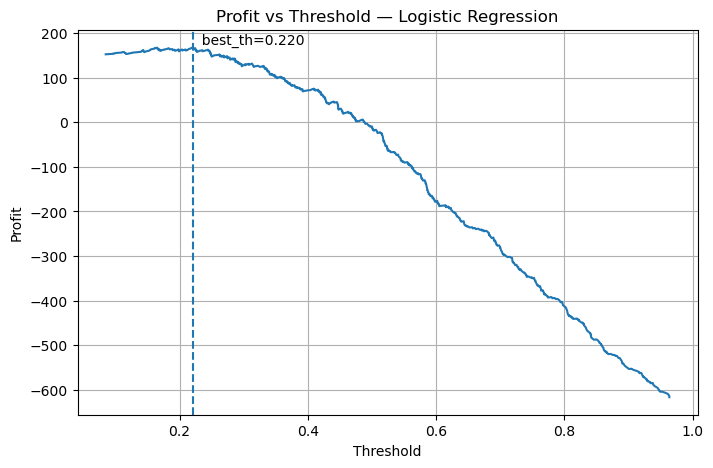

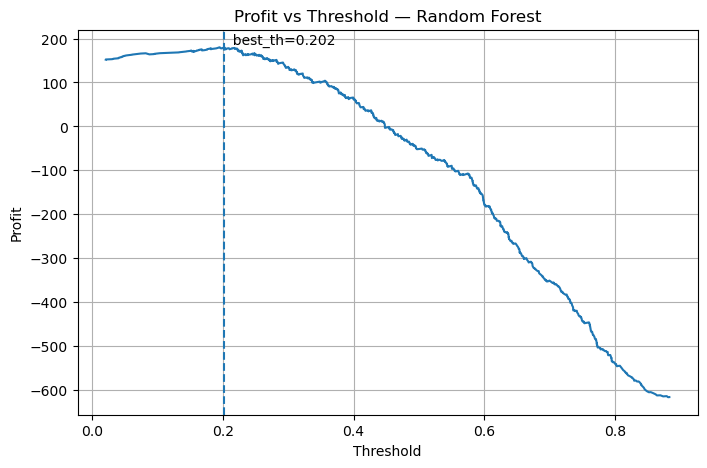

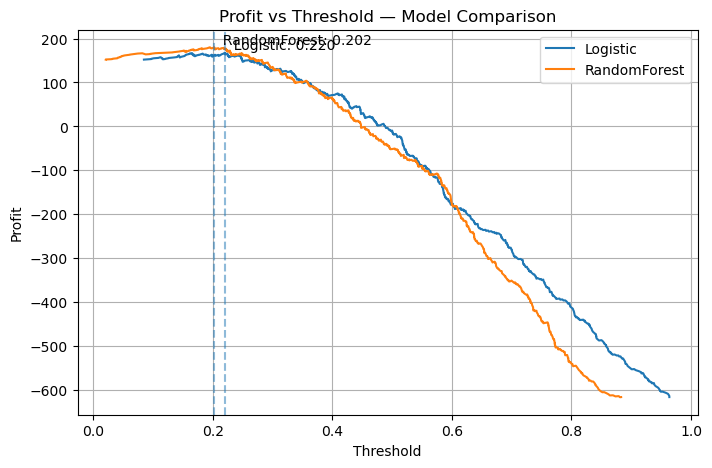

In [11]:
# 최적 파이프라인 추출
logreg_est = gs_log.best_estimator_
rf_est     = gs_rf.best_estimator_

# 1) 각 모델 개별 곡선
plot_profit_curve_single("Logistic Regression", logreg_est, X_test, y_test,
                         revenue_tp=1.0, cost_fp=0.3, cost_fn=1.5, benefit_tn=0.0)

plot_profit_curve_single("Random Forest", rf_est, X_test, y_test,
                         revenue_tp=1.0, cost_fp=0.3, cost_fn=1.5, benefit_tn=0.0)

# 2) 한 플롯에서 비교
plot_profit_curve_compare(
    [("Logistic", logreg_est), ("RandomForest", rf_est)],
    X_test, y_test,
    revenue_tp=1.0, cost_fp=0.3, cost_fn=1.5, benefit_tn=0.0
)

# 저장 불러오는 코드

In [12]:
import joblib

# 저장 파일 경로
model_path = "best_model_with_threshold.pkl"

# 저장할 객체에 모델과 threshold 같이 묶기
model_bundle = {
    "model": best_est,
    "best_threshold": best_th
}

# 저장
joblib.dump(model_bundle, model_path)
print(f"모델과 임계값 저장 완료: {model_path}")


모델과 임계값 저장 완료: best_model_with_threshold.pkl


In [13]:
# 불러오기
loaded_bundle = joblib.load(model_path)

# 모델과 threshold 꺼내기
loaded_model = loaded_bundle["model"]
loaded_threshold = loaded_bundle["best_threshold"]

print("불러온 threshold:", loaded_threshold)


불러온 threshold: 0.20233712253824224


In [14]:
# 예시 입력
sample_case = {
    'rate_marriage': 4.0,
    'age': 35.0,
    'yrs_married': 10.0,
    'children': 2.0,
    'religious': 2.0,
    'educ': 16.0,
    'occupation': 3.0,
    'occupation_husb': 4.0
}

import pandas as pd

df_input = pd.DataFrame([sample_case])

# 예측 확률
prob = loaded_model.predict_proba(df_input)[:, 1][0]

# threshold 적용
pred = int(prob >= loaded_threshold)

print(f"확률: {prob:.4f}, 예측: {pred} (1=affair 있음)")


확률: 0.5933, 예측: 1 (1=affair 있음)
